In [1]:
import numpy as np
import polars as pl
from aeon.datasets.tsc_datasets import univariate
from autotsc import utils

In [2]:
rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()
v = rdf.group_by("model").agg(pl.len()).sort("len", descending=True).collect()
for row in v.iter_rows(named=True):
    print(f"{row['model']}: {row['len']}")

/tmp/ipykernel_4010383/2562833565.py:1: UserWarning: '(default_)region' not set; polars will try to get it from bucket

Set the region manually to silence this warning.
  rdf = pl.scan_parquet("s3://tsc-glue/performance/*.parquet").collect().lazy()


u-rstsf: 640
downsample-mr-hydra: 640
quant: 640
scale-mr-hydra: 640
polar-angle-mr-hydra: 640
drcif: 640
rdst: 640
difference-mr-hydra: 640
mr-hydra: 640
rank-mr-hydra: 640
stacker-v4-r1: 640
cumsum-mr-hydra: 640
rstsf: 640
catch22: 640
polar-magnitude-mr-hydra: 640
hivecotev2: 509
fast-stacker-v4-r1: 159
fast-stacker-v5-r1: 84
fast-stacker-v5-r3: 56
loky-stacker-v5-r1: 24
stacker-v4-r3: 23


In [3]:
df = (
    rdf
    .filter(pl.col("model") != "stacker-v4-r3")
    .filter(pl.col("model") != "difference-mr-hydra")
    .filter(pl.col("model") != "scale-mr-hydra")
    .filter(pl.col("model") != "cumsum-mr-hydra")
    .filter(pl.col("model") != "downsample-mr-hydra")
    .filter(pl.col("model") != "rank-mr-hydra")
    .filter(pl.col("model") != "polar-magnitude-mr-hydra")
    .filter(pl.col("model") != "polar-angle-mr-hydra")
    .filter(pl.col("model") != "catch22")
    #.filter(pl.col("model") != "drcif")
    #.filter(pl.col("model") != "fast-stacker-v5-r3")
    #.filter(pl.col("model") != "fast-stacker-v5-r3")
    .filter(pl.col("model") != "fast-stacker-v4-r1")
    .filter(pl.col("model") != "fast-stacker-v5-r1")
    .filter(pl.col("model") != "fast-stacker-v5-r3")

).collect(engine="streaming")
df

dataset,model,run,resampled,test_accuracy
str,str,i64,bool,f64
"""OSULeaf""","""hivecotev2""",100,false,0.96281
"""InsectWingbeatSound""","""drcif""",400,false,0.632828
"""Trace""","""u-rstsf""",400,false,1.0
"""TwoLeadECG""","""drcif""",500,false,0.982441
"""GesturePebbleZ2""","""stacker-v4-r1""",300,false,0.879747
…,…,…,…,…
"""ScreenType""","""rstsf""",100,false,0.541333
"""ECG200""","""rdst""",300,false,0.9
"""SemgHandGenderCh2""","""stacker-v4-r1""",100,false,0.96


In [4]:
rdf.collect()['model'].unique()

model
str
"""mr-hydra"""
"""stacker-v4-r3"""
"""loky-stacker-v5-r1"""
"""rdst"""
"""fast-stacker-v4-r1"""
…
"""difference-mr-hydra"""
"""quant"""
"""rstsf"""


In [5]:
from aeon.visualisation import plot_critical_difference

In [6]:
v = df.pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).drop_nulls()
methods = df["model"].unique().to_list()
v

dataset,hivecotev2,drcif,u-rstsf,stacker-v4-r1,mr-hydra,quant,rdst,rstsf,loky-stacker-v5-r1
str,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Trace""",1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
"""SemgHandSubjectCh2""",0.913333,0.900889,0.898667,0.904444,0.900444,0.884444,0.858222,0.917778,0.902222
"""NonInvasiveFetalECGThorax2""",0.966794,0.924987,0.936387,0.96916,0.967735,0.948804,0.940153,0.938422,0.969975
"""GunPointAgeSpan""",0.996835,0.982278,0.998734,1.0,1.0,0.999367,0.996835,0.992405,1.0
"""Lightning7""",0.816438,0.728767,0.731507,0.824658,0.830137,0.769863,0.789041,0.761644,0.821918
…,…,…,…,…,…,…,…,…,…
"""HandOutlines""",0.938514,0.916757,0.915676,0.948108,0.94973,0.922703,0.948649,0.912973,0.948649
"""SwedishLeaf""",0.9664,0.9456,0.96416,0.97568,0.97824,0.9616,0.96352,0.95744,0.976
"""Computers""",0.764,0.736,0.7664,0.7856,0.7752,0.792,0.7608,0.74,0.788


(<Figure size 600x280 with 1 Axes>, <Axes: >)

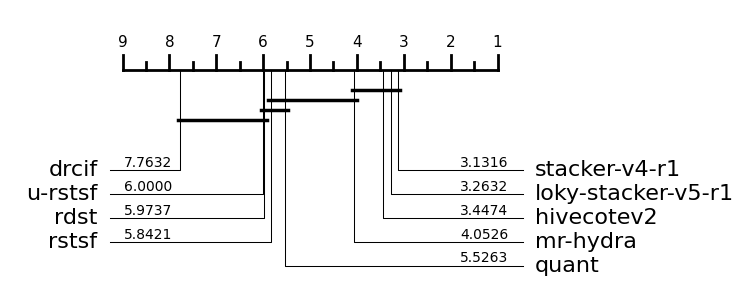

In [7]:
plot_critical_difference(v.select(methods).to_numpy(), methods)

In [8]:
def dataset_stats():

    stats = []
    for dataset in univariate:
        X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
        stats.append(
            {
                "dataset": dataset,
                "n_train": X_train.shape[0],
                "n_test": X_test.shape[0],
                "n_classes": len(np.unique(y_train)),
                "series_length": X_train.shape[2],
            }
        )
    return pl.DataFrame(stats)


stats = dataset_stats()

In [9]:
joined = v.join(stats, on="dataset").sort("n_train")
joined

dataset,hivecotev2,drcif,u-rstsf,stacker-v4-r1,mr-hydra,quant,rdst,rstsf,loky-stacker-v5-r1,n_train,n_test,n_classes,series_length
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,i64,i64,i64,i64
"""DodgerLoopWeekend""",0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,0.984127,18,126,2,288
"""ToeSegmentation2""",0.934615,0.867692,0.895385,0.921538,0.915385,0.86,0.909231,0.883077,0.915385,36,130,2,343
"""Mallat""",0.976226,0.950704,0.951557,0.953859,0.927846,0.954456,0.951045,0.969126,0.946695,55,2345,8,1024
"""Lightning7""",0.816438,0.728767,0.731507,0.824658,0.830137,0.769863,0.789041,0.761644,0.821918,70,73,7,319
"""InlineSkate""",0.533182,0.502182,0.623636,0.586545,0.497091,0.586909,0.447273,0.601818,0.569091,100,550,7,1882
…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""SwedishLeaf""",0.9664,0.9456,0.96416,0.97568,0.97824,0.9616,0.96352,0.95744,0.976,500,625,15,128
"""FaceAll""",0.873225,0.73432,0.764379,0.80071,0.80568,0.77503,0.798225,0.888994,0.799408,560,1690,14,131
"""UWaveGestureLibraryY""",0.777429,0.748967,0.76622,0.810999,0.808208,0.770966,0.764098,0.751982,0.812116,896,3582,8,315


8


(<Figure size 600x280 with 1 Axes>, <Axes: >)

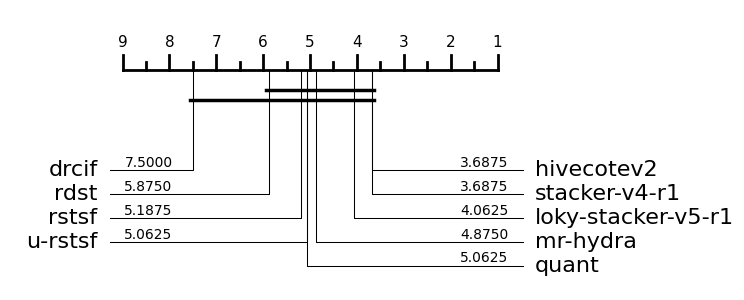

In [10]:
s_small = joined.filter(pl.col("n_train") < 200)
print(len(s_small))
plot_critical_difference(s_small.select(methods).to_numpy(), methods)

8


(<Figure size 600x280 with 1 Axes>, <Axes: >)

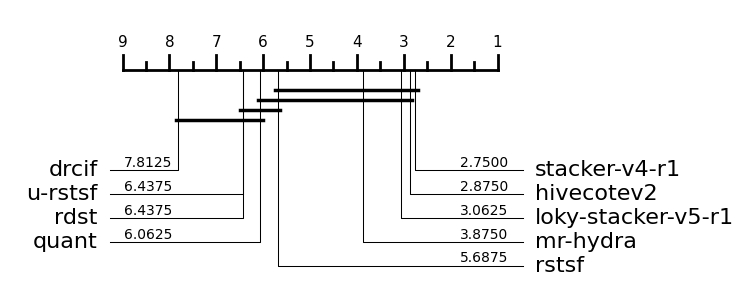

In [11]:
s_medium = joined.filter(pl.col("n_train") >= 200).filter(pl.col("n_train") < 600)
print(len(s_medium))
plot_critical_difference(s_medium.select(methods).to_numpy(), methods)

3


(<Figure size 600x280 with 1 Axes>, <Axes: >)

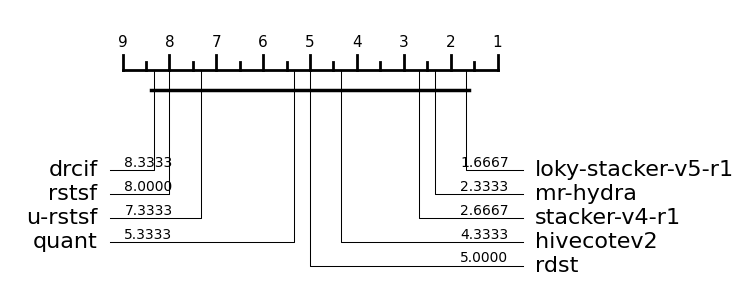

In [12]:
s_large = joined.filter(pl.col("n_train") >= 600)
print(len(s_large))
plot_critical_difference(s_large.select(methods).to_numpy(), methods)

In [13]:
rdf.collect().pivot(
    on="model", values="test_accuracy", index="dataset", aggregate_function="mean"
).sort('downsample-mr-hydra')

dataset,polar-angle-mr-hydra,hivecotev2,downsample-mr-hydra,drcif,scale-mr-hydra,polar-magnitude-mr-hydra,catch22,u-rstsf,stacker-v4-r1,cumsum-mr-hydra,mr-hydra,rank-mr-hydra,fast-stacker-v5-r1,stacker-v4-r3,quant,fast-stacker-v5-r3,fast-stacker-v4-r1,rdst,rstsf,difference-mr-hydra,loky-stacker-v5-r1
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""Phoneme""",0.288502,0.391878,0.327954,0.356224,0.349895,0.354008,0.305802,0.38903,0.349895,0.269093,0.349895,0.34557,null,null,0.382278,null,null,0.337975,0.380907,0.369831,null
"""InlineSkate""",0.436727,0.533182,0.464364,0.502182,0.496727,0.497455,0.434182,0.623636,0.586545,0.431273,0.497091,0.469818,0.584545,null,0.586909,0.598182,0.569091,0.447273,0.601818,0.475273,0.569091
"""ScreenType""",0.488533,0.556267,0.511467,0.529067,0.529067,0.5392,0.501867,0.5504,0.546133,0.48,0.5472,0.495467,0.549333,null,0.5328,null,0.557333,0.5216,0.522133,0.5344,null
"""MiddlePhalanxOutlineAgeGroup""",0.527273,0.575325,0.515584,0.574026,0.580519,0.544156,0.6,0.603896,0.580519,0.579221,0.576623,0.579221,null,null,0.61039,null,0.581169,0.584416,0.597403,0.535065,null
"""RefrigerationDevices""",0.589333,0.552,0.521067,0.592533,0.528,0.524267,0.507733,0.5824,0.577067,0.506133,0.526933,0.5472,0.562667,null,0.581867,null,null,0.5568,0.5904,0.538667,null
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""GunPointOldVersusYoung""",0.996825,1.0,1.0,1.0,0.996825,1.0,1.0,1.0,1.0,0.989841,1.0,0.979683,1.0,null,1.0,null,1.0,1.0,1.0,1.0,null
"""TwoPatterns""",0.99195,1.0,1.0,0.99425,1.0,0.30035,0.8436,0.992,1.0,0.9977,1.0,0.99975,1.0,1.0,0.99995,null,1.0,1.0,0.99645,0.9932,null
"""GunPointMaleVersusFemale""",0.996835,1.0,1.0,0.999367,1.0,1.0,0.990506,1.0,1.0,0.996835,1.0,0.982278,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.996835,1.0


In [14]:
import ray
ray.shutdown()